In [2]:
import zipfile
import glob

with zipfile.ZipFile("wykht8y7tg-1.zip", 'r') as zip_ref:
    zip_ref.extractall("battery_data")

# sorted() so file order stays identical every time you re-run this, on any machine
drive_cycle_files = sorted(glob.glob("battery_data/**/Drive Cycles/*.mat", recursive=True))
print(f"Found {len(drive_cycle_files)} drive cycle files")
for f in drive_cycle_files[:5]:
    print(f)

Found 50 drive cycle files
battery_data/Panasonic 18650PF Data/-10degC/Drive Cycles/06-07-17_08.39 n10degC_HWFET_Pan18650PF.mat
battery_data/Panasonic 18650PF Data/-10degC/Drive Cycles/06-07-17_08.39 n10degC_LA92_Pan18650PF.mat
battery_data/Panasonic 18650PF Data/-10degC/Drive Cycles/06-07-17_08.39 n10degC_UDDS_Pan18650PF.mat
battery_data/Panasonic 18650PF Data/-10degC/Drive Cycles/06-07-17_08.39 n10degC_US06_HWFET_UDDS_LA92_Pan18650PF.mat
battery_data/Panasonic 18650PF Data/-10degC/Drive Cycles/06-07-17_08.39 n10degC_US06_Pan18650PF.mat


In [3]:
train_file = [f for f in drive_cycle_files if "Cycle_2" in f][0]
print("Using:", train_file)

Using: battery_data/Panasonic 18650PF Data/-10degC/Drive Cycles/06-10-17_18.35 n10degC_Cycle_2_Pan18650PF.mat


In [4]:
from scipy.io import loadmat

mat = loadmat(train_file, squeeze_me=True, struct_as_record=False)
meas = mat["meas"]
print("Fields available:", meas._fieldnames)

Fields available: ['TimeStamp', 'Voltage', 'Current', 'Ah', 'Wh', 'Power', 'Battery_Temp_degC', 'Time', 'Chamber_Temp_degC']


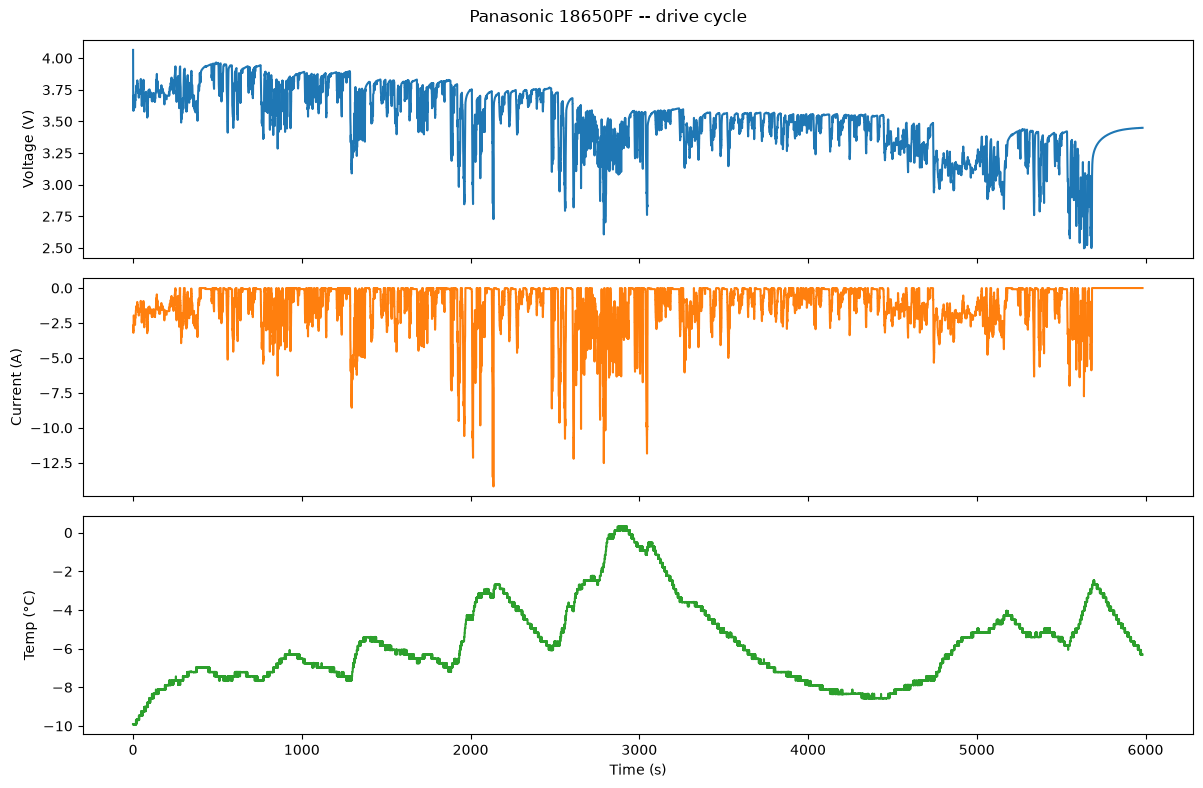

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "time_s": meas.Time,
    "voltage_V": meas.Voltage,
    "current_A": meas.Current,
    "temp_C": meas.Battery_Temp_degC,
    "ah": meas.Ah,
})

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(df["time_s"], df["voltage_V"], color="tab:blue")
axes[0].set_ylabel("Voltage (V)")
axes[1].plot(df["time_s"], df["current_A"], color="tab:orange")
axes[1].set_ylabel("Current (A)")
axes[2].plot(df["time_s"], df["temp_C"], color="tab:green")
axes[2].set_ylabel("Temp (°C)")
axes[2].set_xlabel("Time (s)")
plt.suptitle("Panasonic 18650PF -- drive cycle")
plt.tight_layout()
plt.show()

In [6]:
import numpy as np

# The Panasonic 18650PF cell is rated at 2.9 Amp-hours when brand new
CAPACITY_AH = 2.9

time_s = df["time_s"].values
current_A = df["current_A"].values

# Time step in hours (capacity is in Amp-HOURS, current is in Amps)
dt_hours = np.diff(time_s, prepend=time_s[0]) / 3600.0

# THIS is Coulomb counting: multiply current by time-elapsed at each step,
# then keep a running total. Positive current = charging in this dataset,
# so this running total directly tracks charge gained or lost.
ah_change = np.cumsum(current_A * dt_hours)
soc_ours = (1 + (ah_change / CAPACITY_AH)) * 100
df["soc_coulomb_counting"] = soc_ours

print(df[["time_s", "current_A", "soc_coulomb_counting"]].head(10))

     time_s  current_A  soc_coulomb_counting
0  0.000000   -2.68831            100.000000
1  0.096992   -2.78141             99.997416
2  0.199999   -2.85082             99.994603
3  0.298993   -2.92268             99.991832
4  0.395995   -2.97413             99.989068
5  0.497000   -3.01088             99.986155
6  0.597995   -3.04354             99.983211
7  0.697995   -3.06314             99.980277
8  0.796998   -3.08192             99.977355
9  0.897994   -3.09499             99.974361


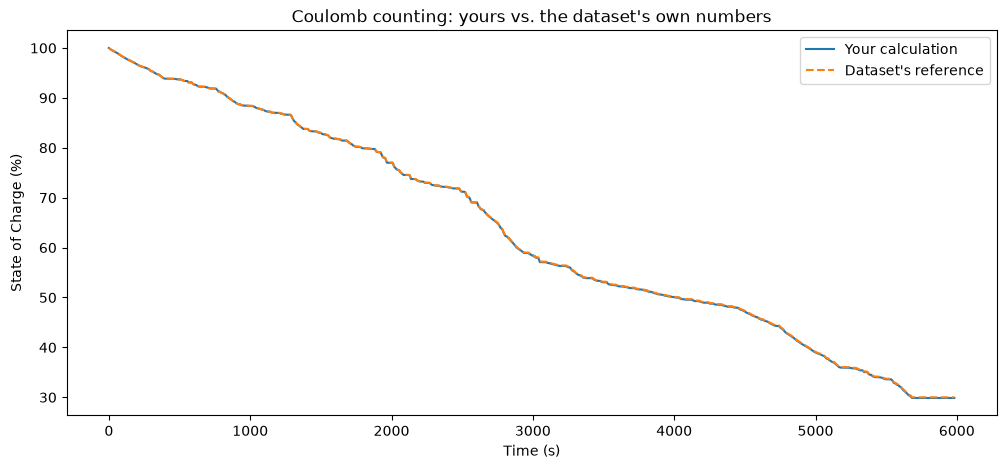

In [7]:
ah_theirs = meas.Ah
soc_theirs = (1 + (ah_theirs / CAPACITY_AH)) * 100
df["soc_dataset_reference"] = soc_theirs

plt.figure(figsize=(12, 5))
plt.plot(df["time_s"], df["soc_coulomb_counting"], label="Your calculation")
plt.plot(df["time_s"], df["soc_dataset_reference"], label="Dataset's reference", linestyle="--")
plt.xlabel("Time (s)")
plt.ylabel("State of Charge (%)")
plt.title("Coulomb counting: yours vs. the dataset's own numbers")
plt.legend()
plt.show()

In [8]:
tail = df.tail(int(len(df) * 0.2))
print("Difference between your estimate and the reference, near the end:")
print((tail["soc_coulomb_counting"] - tail["soc_dataset_reference"]).describe())

Difference between your estimate and the reference, near the end:
count    11942.000000
mean        -0.122909
std          0.009929
min         -0.141857
25%         -0.138468
50%         -0.117223
75%         -0.115648
max         -0.113624
dtype: float64


Using 28148 low-current samples out of 59712 total
Fitted internal resistance R0 = 0.0994 ohms


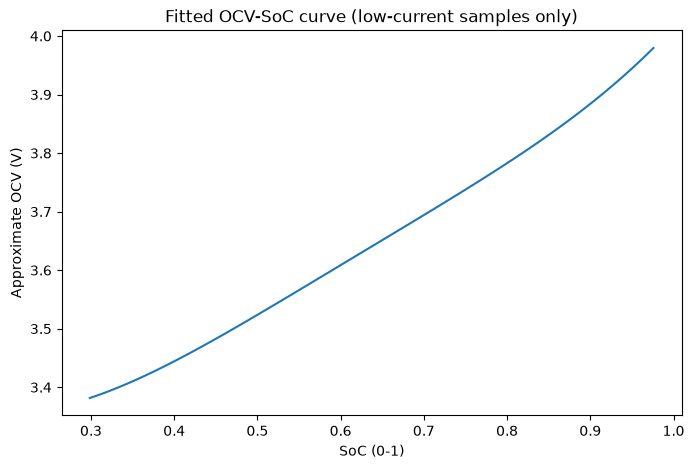

In [9]:
import numpy as np

soc_data = df["soc_coulomb_counting"].values / 100.0
voltage_data = df["voltage_V"].values

# Only use "quiet" moments -- current close to zero -- so loading barely distorts voltage
low_current_mask = np.abs(current_A) < 0.5
soc_quiet = soc_data[low_current_mask]
voltage_quiet = voltage_data[low_current_mask]
print(f"Using {low_current_mask.sum()} low-current samples out of {len(df)} total")

ocv_coeffs = np.polyfit(soc_quiet, voltage_quiet, deg=4)
ocv_poly = np.poly1d(ocv_coeffs)
docv_dsoc = ocv_poly.deriv()

# Solve for internal resistance from whatever voltage gap is left over
# after subtracting the clean OCV curve -- rather than guessing a value
predicted_ocv_all = ocv_poly(soc_data)
residual = voltage_data - predicted_ocv_all
R0_fit = np.sum(residual * current_A) / np.sum(current_A ** 2)
print(f"Fitted internal resistance R0 = {R0_fit:.4f} ohms")

soc_range = np.linspace(soc_quiet.min(), soc_quiet.max(), 100)
plt.figure(figsize=(8, 5))
plt.plot(soc_range, ocv_poly(soc_range))
plt.xlabel("SoC (0-1)")
plt.ylabel("Approximate OCV (V)")
plt.title("Fitted OCV-SoC curve (low-current samples only)")
plt.show()

In [10]:
Q_noise = 1e-8      # how much we trust the Coulomb-counting prediction
R_noise = 0.08        # how much we trust the voltage measurement

soc_est = 1.0
P = 1e-3

soc_kalman = []

for i in range(len(df)):
    I = current_A[i]
    dt_h = dt_hours[i]

    # PREDICT: identical logic to Day 2's Coulomb counting
    soc_pred = soc_est + (I * dt_h) / CAPACITY_AH
    P_pred = P + Q_noise

    # UPDATE: check against the actual voltage reading
    voltage_measured = voltage_data[i]
    voltage_predicted = ocv_poly(soc_pred) + I * R0_fit
    H = docv_dsoc(soc_pred)

    innovation = voltage_measured - voltage_predicted
    S = H * P_pred * H + R_noise
    K = P_pred * H / S

    soc_est = soc_pred + K * innovation
    P = (1 - K * H) * P_pred

    soc_kalman.append(soc_est * 100)

df["soc_kalman_filter"] = soc_kalman

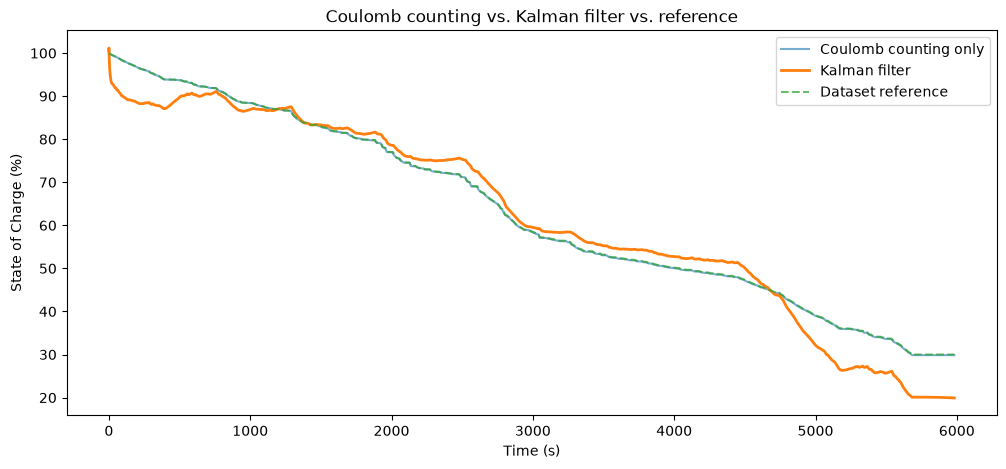

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(df["time_s"], df["soc_coulomb_counting"], label="Coulomb counting only", alpha=0.6)
plt.plot(df["time_s"], df["soc_kalman_filter"], label="Kalman filter", linewidth=2)
plt.plot(df["time_s"], df["soc_dataset_reference"], label="Dataset reference", linestyle="--", alpha=0.7)
plt.xlabel("Time (s)")
plt.ylabel("State of Charge (%)")
plt.title("Coulomb counting vs. Kalman filter vs. reference")
plt.legend()
plt.show()

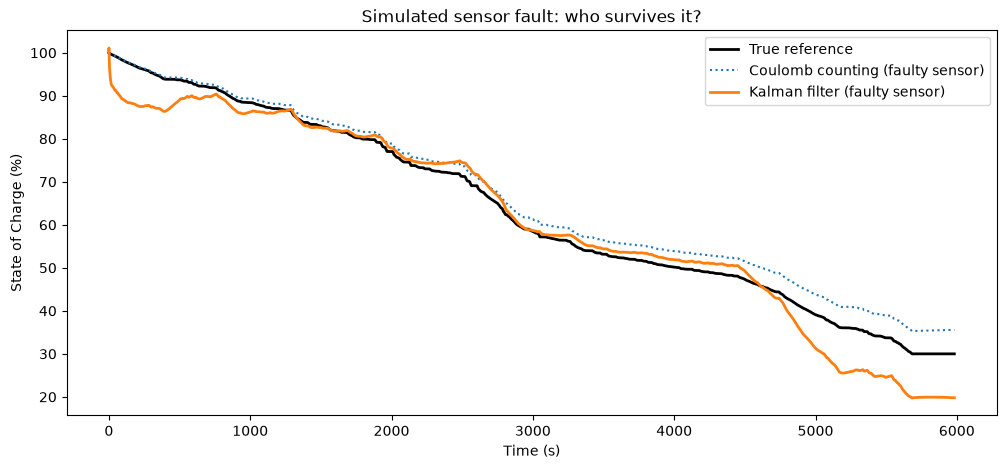

In [12]:
fake_bias_A = 0.1   # pretend our current sensor is always reading 0.1A off

current_biased = current_A + fake_bias_A

# Coulomb counting alone, using the FAULTY current
soc_broken = [100.0]
for i in range(1, len(df)):
    step = soc_broken[-1] + (current_biased[i] * dt_hours[i] / CAPACITY_AH) * 100
    soc_broken.append(step)
df["soc_coulomb_biased"] = soc_broken

# The Kalman filter, using the EXACT SAME faulty current
soc_est = 1.0
P = 1e-3
soc_kalman_biased = []
for i in range(len(df)):
    I = current_biased[i]
    dt_h = dt_hours[i]
    soc_pred = soc_est + (I * dt_h) / CAPACITY_AH
    P_pred = P + Q_noise
    voltage_measured = voltage_data[i]
    voltage_predicted = ocv_poly(soc_pred) + I * R0_fit
    H = docv_dsoc(soc_pred)
    innovation = voltage_measured - voltage_predicted
    S = H * P_pred * H + R_noise
    K = P_pred * H / S
    soc_est = soc_pred + K * innovation
    P = (1 - K * H) * P_pred
    soc_kalman_biased.append(soc_est * 100)
df["soc_kalman_biased"] = soc_kalman_biased

plt.figure(figsize=(12, 5))
plt.plot(df["time_s"], df["soc_dataset_reference"], label="True reference", linewidth=2, color="black")
plt.plot(df["time_s"], df["soc_coulomb_biased"], label="Coulomb counting (faulty sensor)", linestyle=":")
plt.plot(df["time_s"], df["soc_kalman_biased"], label="Kalman filter (faulty sensor)", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("State of Charge (%)")
plt.title("Simulated sensor fault: who survives it?")
plt.legend()
plt.show()

In [13]:
import os
from scipy.io import loadmat

# Find which temperature folder your existing file (train_file) lives in,
# so we grab companion drive cycles from the SAME temperature
temp_folder = train_file.split("/Drive Cycles/")[0]
print("Temperature folder:", temp_folder)

train_names = ["Cycle_1", "Cycle_3", "Cycle_4", "US06"]
multi_train_files = [f for f in drive_cycle_files
                      if f.startswith(temp_folder) and any(name in f for name in train_names)]

# Safety net: if none of those exact names matched what's actually on disk,
# just grab any other files from the same temperature folder instead
if len(multi_train_files) < 2:
    print("Named files not found -- falling back to any other files in this temperature folder")
    multi_train_files = [f for f in drive_cycle_files
                          if f.startswith(temp_folder) and f != train_file][:4]

print(f"Training on {len(multi_train_files)} files:")
for f in multi_train_files:
    print(" ", f)

CAPACITY_AH = 2.9

def load_drive_cycle(filepath):
    mat = loadmat(filepath, squeeze_me=True, struct_as_record=False)
    m = mat["meas"]
    d = pd.DataFrame({
        "time_s": m.Time,
        "voltage_V": m.Voltage,
        "current_A": m.Current,
        "temp_C": m.Battery_Temp_degC,
        "ah": m.Ah,
    })
    d["soc_true"] = (1 + d["ah"] / CAPACITY_AH) * 100
    return d

train_dfs = [load_drive_cycle(f) for f in multi_train_files]
for i, d in enumerate(train_dfs):
    print(f"File {i}: {len(d)} rows")

# Give your existing df the same "soc_true" column name for consistency
df["soc_true"] = df["soc_dataset_reference"]

Temperature folder: battery_data/Panasonic 18650PF Data/-10degC
Training on 5 files:
  battery_data/Panasonic 18650PF Data/-10degC/Drive Cycles/06-07-17_08.39 n10degC_US06_HWFET_UDDS_LA92_Pan18650PF.mat
  battery_data/Panasonic 18650PF Data/-10degC/Drive Cycles/06-07-17_08.39 n10degC_US06_Pan18650PF.mat
  battery_data/Panasonic 18650PF Data/-10degC/Drive Cycles/06-10-17_11.25 n10degC_Cycle_1_Pan18650PF.mat
  battery_data/Panasonic 18650PF Data/-10degC/Drive Cycles/06-11-17_01.39 n10degC_Cycle_3_Pan18650PF.mat
  battery_data/Panasonic 18650PF Data/-10degC/Drive Cycles/06-11-17_08.42 n10degC_Cycle_4_Pan18650PF.mat
File 0: 288435 rows
File 1: 31197 rows
File 2: 60234 rows
File 3: 56857 rows
File 4: 61102 rows


In [14]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

feature_cols = ["voltage_V", "current_A", "temp_C"]

all_train_features = pd.concat([d[feature_cols] for d in train_dfs], ignore_index=True)
scaler = MinMaxScaler()
scaler.fit(all_train_features)

def make_sequences(features_scaled, targets, window_size=100):
    X, y = [], []
    for i in range(window_size, len(features_scaled)):
        X.append(features_scaled[i-window_size:i])
        y.append(targets[i])
    return np.array(X), np.array(y)

WINDOW = 100

X_train_list, y_train_list = [], []
for d in train_dfs:
    feats_scaled = scaler.transform(d[feature_cols])
    X_d, y_d = make_sequences(feats_scaled, d["soc_true"].values, WINDOW)
    X_train_list.append(X_d)
    y_train_list.append(y_d)

X_train = np.concatenate(X_train_list, axis=0)
y_train = np.concatenate(y_train_list, axis=0)
print("Combined training sequences:", X_train.shape)

# Test data: your existing file from Days 1-3 -- never shown to the model during training
test_features_scaled = scaler.transform(df[feature_cols])
X_test, y_test = make_sequences(test_features_scaled, df["soc_true"].values, WINDOW)

soc_scaler = MinMaxScaler()
y_train_scaled = soc_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = soc_scaler.transform(y_test.reshape(-1, 1)).flatten()

Combined training sequences: (497325, 100, 3)


In [15]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Input(shape=(WINDOW, len(feature_cols))),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.LSTM(32),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1)
])
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train_scaled,
    validation_data=(X_test, y_test_scaled),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 64)        │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,369 (118.63 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
3886/3886 ━━━━━━━━━━━━━━━━━━━━ 347s 89ms/step - loss: 0.0013 - mae: 0.0227 - val_loss: 5.6561e-04 - val_mae: 0.0191
Epoch 2/30
3886/3886 ━━━━━━━━━━━━━━━━━━━━ 348s 89ms/step - loss: 8.4311e-04 - mae: 0.0190 - val_loss: 5.2399e-04 - val_mae: 0.0178
Epoch 3/30
3886/3886 ━━━━━━━━━━━━━━━━━━━━ 314s 81ms/step - loss: 8.1686e-04 - mae: 0.0180 - val_loss: 5.0939e-04 - val_mae: 0.0172
Epoch 4/30
3886/3886 ━━━━━━━━━━━━━━━━━━━━ 359s 92ms/step - loss: 9.0190e-04 - mae: 0.0185 - val_loss: 0.0012 - val_mae: 0.0251
Epoch 5/30
3886/3886 ━━━━━━━━━━━━━━━━━━━━ 352s 91ms/step - loss: 8.4168e-04 - mae: 0.0181 - val_loss: 6.5541e-04 - val_mae: 0.0196
Epoch 6/30
3886/3886 ━━━━━━━━━━━━━━━━━━━━ 351s 90ms/step - loss: 8.1590e-04 - mae: 0.0184 - val_loss: 3.8251e-04 - val_mae: 0.0159
Epoch 7/30
3886/3886 ━━━━━━━━━━━━━━━━━━━━ 327s 84ms/step - loss: 5.7534e-04 - mae: 0.0158 - val_loss: 3.4277e-04 - val_mae: 0.0146
Epoch 8/30
3886/3886 ━━━━━━━━━━━━━━━━━━━━ 337s 87ms/step - loss: 8.0397e-04 - mae: 0.0177 -

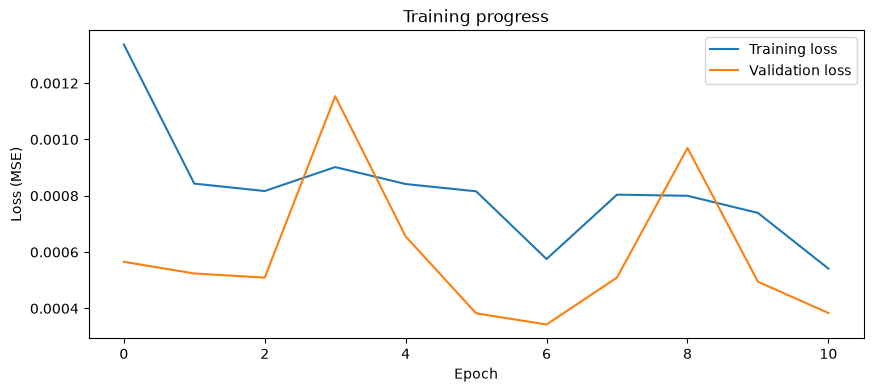

1863/1863 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step


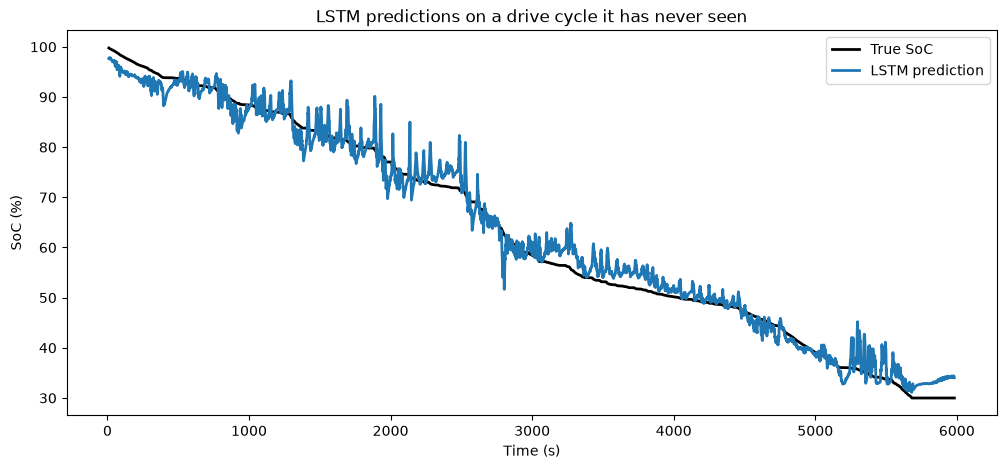

LSTM -- MAE: 2.03%, RMSE: 2.58%


In [16]:
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.title("Training progress")
plt.show()

predictions_scaled = model.predict(X_test).flatten()
predictions = soc_scaler.inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()

true_soc_aligned = df["soc_true"].values[WINDOW:]
time_aligned = df["time_s"].values[WINDOW:]

plt.figure(figsize=(12, 5))
plt.plot(time_aligned, true_soc_aligned, label="True SoC", color="black", linewidth=2)
plt.plot(time_aligned, predictions, label="LSTM prediction", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("SoC (%)")
plt.title("LSTM predictions on a drive cycle it has never seen")
plt.legend()
plt.show()

from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(true_soc_aligned, predictions)
rmse = np.sqrt(mean_squared_error(true_soc_aligned, predictions))
print(f"LSTM -- MAE: {mae:.2f}%, RMSE: {rmse:.2f}%")

In [17]:
import joblib

os.makedirs("checkpoints", exist_ok=True)
model.save("checkpoints/lstm_model.keras")
joblib.dump(scaler, "checkpoints/feature_scaler.pkl")
joblib.dump(soc_scaler, "checkpoints/soc_scaler.pkl")
print("Saved. Next session, load these instead of retraining.")

Saved. Next session, load these instead of retraining.


In [18]:
from tensorflow import keras
import joblib

model = keras.models.load_model("checkpoints/lstm_model.keras")
scaler = joblib.load("checkpoints/feature_scaler.pkl")
soc_scaler = joblib.load("checkpoints/soc_scaler.pkl")

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

true_vals = df["soc_true"].values[WINDOW:]
time_vals = df["time_s"].values[WINDOW:]

coulomb_vals = df["soc_coulomb_counting"].values[WINDOW:]
kalman_vals = df["soc_kalman_filter"].values[WINDOW:]
lstm_vals = predictions   # from Day 4, Part 4

results = {}
for name, vals in [("Coulomb counting", coulomb_vals),
                    ("Kalman filter", kalman_vals),
                    ("LSTM", lstm_vals)]:
    mae = mean_absolute_error(true_vals, vals)
    rmse = np.sqrt(mean_squared_error(true_vals, vals))
    results[name] = {"MAE (%)": round(mae, 2), "RMSE (%)": round(rmse, 2)}
    print(f"{name:20s}  MAE: {mae:.2f}%   RMSE: {rmse:.2f}%")

comparison_df = pd.DataFrame(results).T
print(comparison_df)

Coulomb counting      MAE: 0.07%   RMSE: 0.09%
Kalman filter         MAE: 3.60%   RMSE: 4.66%
LSTM                  MAE: 2.03%   RMSE: 2.58%
                  MAE (%)  RMSE (%)
Coulomb counting     0.07      0.09
Kalman filter        3.60      4.66
LSTM                 2.03      2.58


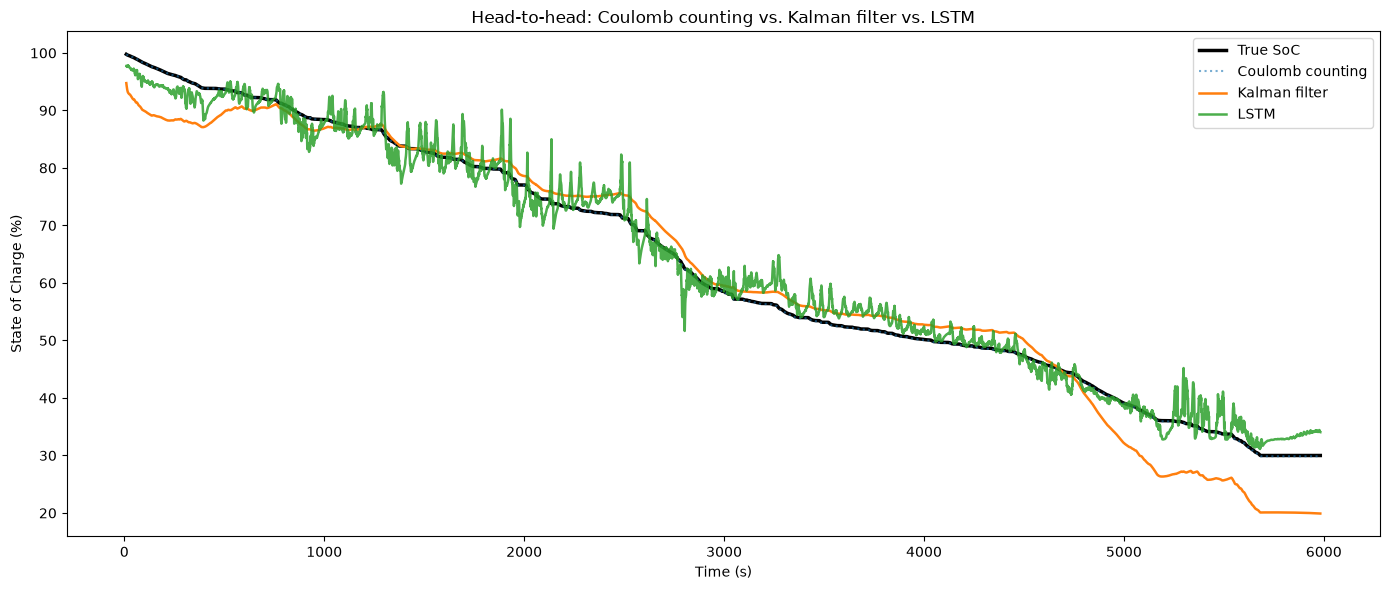

In [20]:
plt.figure(figsize=(14, 6))
plt.plot(time_vals, true_vals, label="True SoC", color="black", linewidth=2.5)
plt.plot(time_vals, coulomb_vals, label="Coulomb counting", alpha=0.6, linestyle=":")
plt.plot(time_vals, kalman_vals, label="Kalman filter", linewidth=1.8)
plt.plot(time_vals, lstm_vals, label="LSTM", linewidth=1.8, alpha=0.85)
plt.xlabel("Time (s)")
plt.ylabel("State of Charge (%)")
plt.title("Head-to-head: Coulomb counting vs. Kalman filter vs. LSTM")
plt.legend()
plt.tight_layout()
plt.savefig("comparison_plot.png", dpi=150)
plt.show()